# 01 — Geometry, causal splits, and physics baselines

*I built this learning notebook from synthetic examples and committed aggregate results so that licensed ZOD samples remain outside Git.*

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## Learning objectives and one supervised sample

After this notebook I should be able to derive the anchor-local target, explain
every input channel, implement CV/CTRV, and defend recording-level splits.

One sample contains 21 rows at 10 Hz. Its nine causal channels are speed $v$,
longitudinal acceleration $a$, yaw rate $r$, steering angle $\delta$,
accelerator ratio, brake flag, left/right indicators, and observation age
$\Delta t$. A Boolean mask with the same shape records freshness and finiteness.
The output contains 30 future $(x,y)$ positions at 10 Hz.

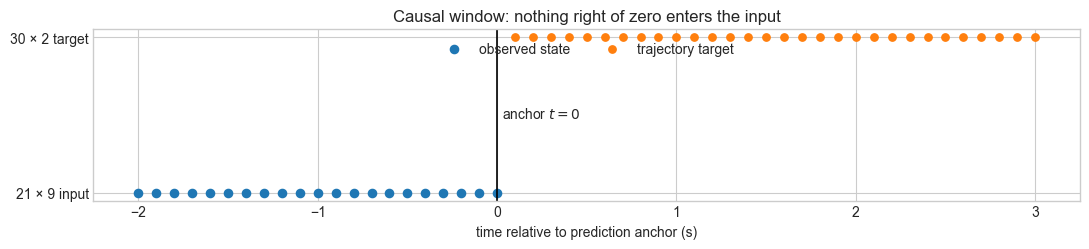

In [2]:
history_t = np.arange(-20, 1) * .1
future_t = np.arange(1, 31) * .1
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.scatter(history_t, np.zeros_like(history_t), label="observed state", s=35)
ax.scatter(future_t, np.ones_like(future_t), label="trajectory target", s=28)
ax.axvline(0, color="black", lw=1.2); ax.text(.03, .48, "anchor $t=0$")
ax.set_yticks([0,1], ["21 × 9 input", "30 × 2 target"])
ax.set_xlabel("time relative to prediction anchor (s)")
ax.set_title("Causal window: nothing right of zero enters the input")
ax.legend(loc="upper center", ncol=2); plt.tight_layout(); plt.show()

## From world poses to a local learning target

Let $T^w_t$ map the vehicle frame at time $t$ into the world. I anchor every
future at $t=0$:

\[
T^0_t=(T^w_0)^{-1}T^w_t,
\qquad \mathbf y_t=[T^0_t]_{x,y}.
\]

The inverse is essential. Subtracting world translations alone would leave the
target rotated by global heading. Local coordinates make “forward” comparable
across Sweden, Germany, and France. In 2-D, $T=[R\;p;\;0\;1]$ and
$T^{-1}=[R^\top\;-R^\top p;\;0\;1]$, so
$p^0_t=R_0^\top(p^w_t-p^w_0)$: translate to the anchor and undo its heading.

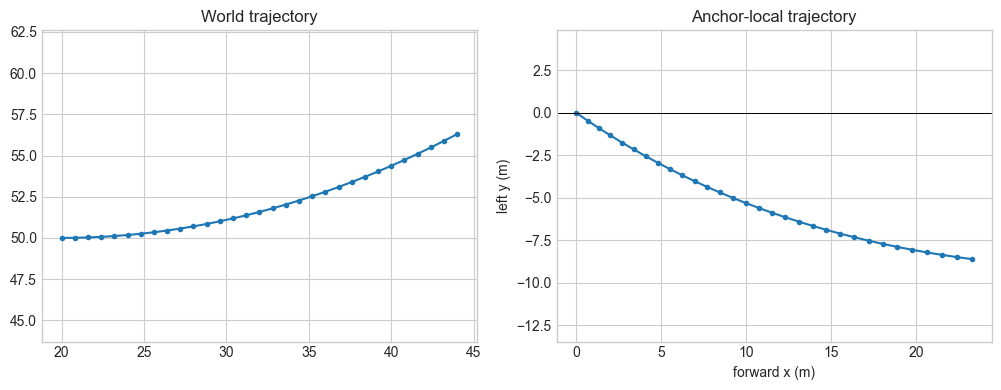

In [3]:
def pose2d(x, y, yaw):
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s, x], [s, c, y], [0, 0, 1.0]])

t = np.linspace(0, 3, 31)
world = np.stack([20 + 8*t, 50 + 0.7*t**2], axis=1)
yaw0 = np.deg2rad(35)
anchor = pose2d(*world[0], yaw0)
homogeneous = np.c_[world, np.ones(len(world))]
local = (np.linalg.inv(anchor) @ homogeneous.T).T[:, :2]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(world[:,0], world[:,1], marker='.')
ax[0].set_title("World trajectory")
ax[0].axis('equal')
ax[1].plot(local[:,0], local[:,1], marker='.')
ax[1].axhline(0, color='k', lw=.7)
ax[1].set_title("Anchor-local trajectory")
ax[1].set_xlabel("forward x (m)"); ax[1].set_ylabel("left y (m)")
ax[1].axis('equal'); plt.tight_layout(); plt.show()

## Normalization and missingness are different information

Train-only statistics give

\[
\tilde x_{t,j}=\frac{x_{t,j}-\mu_j}{s_j}.
\]

Invalid entries are filled with zero *after normalization* and accompanied by
$m_{t,j}\in\{0,1\}$. Thus zero means “equal to the train mean” when $m=1$,
or “missing” when $m=0$. Fitting $\mu_j,s_j$ on validation or test would leak
their feature distribution into training.

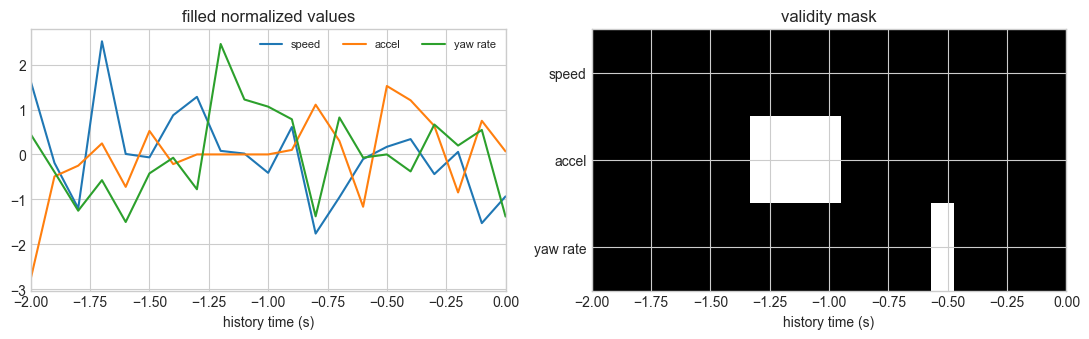

In [4]:
rng = np.random.default_rng(3)
raw = rng.normal([12.0, 0.0, 0.02], [3.0, 1.2, .08], size=(21,3))
valid = np.ones_like(raw, dtype=bool); valid[7:11, 1] = False; valid[15, 2] = False
mean = np.nanmean(np.where(valid, raw, np.nan), axis=0)
scale = np.nanstd(np.where(valid, raw, np.nan), axis=0)
normalized = np.where(valid, (raw-mean)/scale, 0.0)
fig, ax = plt.subplots(1,2,figsize=(11,3.5), sharex=True)
ax[0].plot(history_t, normalized); ax[0].set_title("filled normalized values")
ax[0].legend(["speed", "accel", "yaw rate"], ncol=3, fontsize=8)
ax[1].imshow(valid.T, aspect="auto", cmap="Greys", extent=[-2,0,2.5,-.5])
ax[1].set_yticks([0,1,2], ["speed","accel","yaw rate"]); ax[1].set_title("validity mask")
for axis in ax: axis.set_xlabel("history time (s)")
plt.tight_layout(); plt.show()

## CV and CTRV

Constant velocity predicts $(vt,0)$. Constant turn-rate and velocity integrates
heading $\psi(t)=rt$:

\[
x(t)=\frac vr\sin(rt),\qquad
y(t)=\frac vr(1-\cos(rt)).
\]

As $r\to0$, these equations approach CV. A robust implementation
uses the straight limit near zero instead of dividing by a tiny yaw rate.

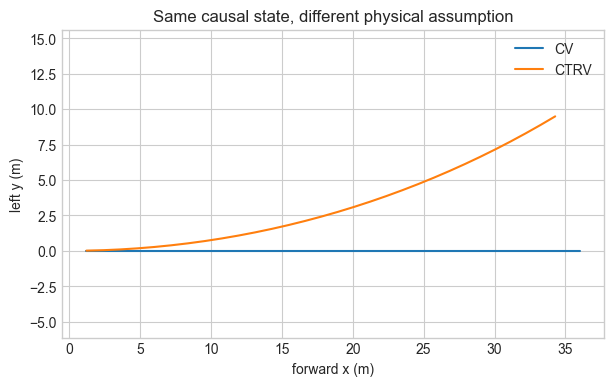

In [5]:
from zod_driveformer.models.baselines import constant_velocity, constant_turn_rate_velocity
speed, yaw_rate = 12.0, 0.18
cv = constant_velocity(speed, future_steps=30, dt=.1)
ctrv = constant_turn_rate_velocity(speed, yaw_rate, future_steps=30, dt=.1)
plt.figure(figsize=(7,4))
plt.plot(cv[:,0], cv[:,1], label='CV')
plt.plot(ctrv[:,0], ctrv[:,1], label='CTRV')
plt.axis('equal'); plt.xlabel('forward x (m)'); plt.ylabel('left y (m)')
plt.title('Same causal state, different physical assumption'); plt.legend(); plt.show()

## Why splits use complete recordings

Two neighboring windows can share nearly every state sample and future target.
Randomly splitting windows would put near-duplicates on both sides. The model
would appear to generalize while recognizing recording-specific dynamics.

If $g(i)$ is the recording containing window $i$, then for every pair of roles
$a\ne b$ the contract is
$\{g(i):i\in\mathcal D_a\}\cap\{g(i):i\in\mathcal D_b\}=\varnothing$.
This is stronger than merely having distinct row indices.

In [6]:
rng = np.random.default_rng(7)
recordings = np.repeat(np.arange(12), rng.integers(20, 45, size=12))
random_test = rng.random(len(recordings)) < .2
leaked_groups = set(recordings[random_test]) & set(recordings[~random_test])
group_test = np.isin(recordings, [1, 6, 10])
clean_overlap = set(recordings[group_test]) & set(recordings[~group_test])
print("Random-window split leaks recording groups:", sorted(leaked_groups))
print("Complete-recording split overlap:", clean_overlap)

Random-window split leaks recording groups: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Complete-recording split overlap: set()


## From point errors to ADE, FDE, and miss rate

Let $e_t=\lVert\hat y_t-y_t\rVert_2$. Then

\[
\operatorname{ADE}=\frac1T\sum_{t=1}^T e_t,\qquad
\operatorname{FDE}=e_T,\qquad
\operatorname{miss}=\mathbb 1[e_T>2\text{ m}].
\]

ADE rewards the whole path while FDE emphasizes the horizon endpoint. Neither
metric establishes closed-loop control stability.

ADE=0.916 m, FDE=1.833 m, miss=False


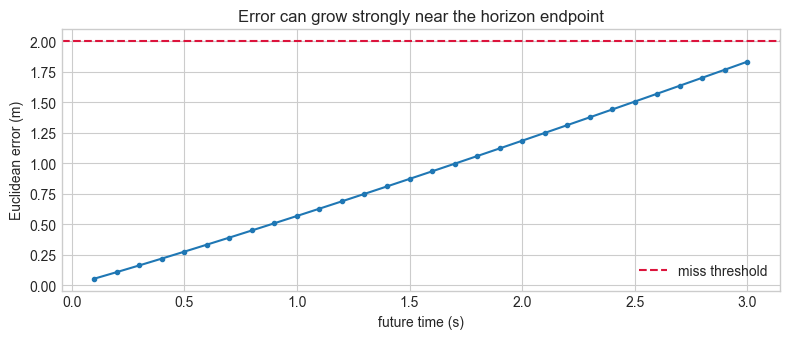

In [7]:
target = ctrv
biased = ctrv + np.c_[.05*np.arange(1,31), .015*np.arange(1,31)**1.25]
errors = np.linalg.norm(biased-target, axis=1)
print(f"ADE={errors.mean():.3f} m, FDE={errors[-1]:.3f} m, miss={errors[-1] > 2.0}")
plt.figure(figsize=(8,3.5)); plt.plot(future_t, errors, marker="o", ms=3)
plt.axhline(2, color="crimson", ls="--", label="miss threshold")
plt.xlabel("future time (s)"); plt.ylabel("Euclidean error (m)")
plt.title("Error can grow strongly near the horizon endpoint")
plt.legend(); plt.tight_layout(); plt.show()

## Actual baseline lesson

CTRV improves CV from 1.036 m to 0.849 m ADE, so yaw rate contains useful
causal information. B2 improves further to 0.673 m by learning from two seconds
of state history. The new models must beat this learned reference, not merely CV.

### Check my understanding

- The anchor inverse makes a north-facing straight path point along local $+x$.
- The mask distinguishes a missing value from a valid value at the train mean.
- CTRV is a stronger turning baseline because it uses causal yaw rate.